## 2. Preprocesamiento y modelado

En esta sección se aborda el **preprocesamiento de texto**, la **construcción de features**, la **selección de modelos supervisados** y el **entrenamiento**, preparando los datos para la predicción de sentimiento de las reseñas.


In [1]:
# =============================================
# Configuración inicial del entorno
# =============================================

# -----------------------------
# Librerías principales
# -----------------------------
import numpy as np
import pandas as pd
import random
import json
import os
import gc
import warnings
from collections import Counter

warnings.filterwarnings("ignore")

# -----------------------------
# Visualización
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud

plt.style.use("seaborn-v0_8")
sns.set_context("notebook")
sns.set_theme(style="whitegrid")

# -----------------------------
# Procesamiento de texto (NLP)
# -----------------------------
import re
import string
import unicodedata
import nltk
import contractions
import spacy

# NLTK
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer, WordNetLemmatizer

# Descargar solo la primera vez
# nltk.download("stopwords")
# nltk.download("punkt")
# nltk.download("wordnet")

STOPWORDS_ES = set(stopwords.words("spanish"))
STOPWORDS_EN = set(stopwords.words("english"))

stemmer_en = SnowballStemmer("english")
lemmatizer = WordNetLemmatizer()
nlp = spacy.load("en_core_web_sm")

# -----------------------------
# Feature Engineering (Texto)
# -----------------------------
from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)

from sklearn.decomposition import (
    TruncatedSVD,
    PCA
)

# -----------------------------
# Modelado clásico (ML)
# -----------------------------
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GroupShuffleSplit,
    GridSearchCV
)

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# -----------------------------
# Transformers (opcional)
# -----------------------------
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

# -----------------------------
# Configuración de dispositivo
# -----------------------------
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo en uso: {DEVICE}")

Dispositivo en uso: cpu


In [2]:
# Se carga de nuevo el df
df = pd.read_json("Movies_and_TV_5_subset.json", lines=True)

In [3]:
# Selección de variable objetivo

# Etiqueta binaria
df['target'] = (df.overall >= 4).astype(int)   # 1 = positivo, 0 = negativo

# Verifica proporciones
print(df.target.value_counts(normalize=True))

target
1    0.79183
0    0.20817
Name: proportion, dtype: float64


In [4]:
# Split por grupos
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(
        gss.split(df, y=df['target'], groups=df['asin'])
)
train_df = df.iloc[train_idx]
test_df  = df.iloc[test_idx]

# Resultados
for name, part in [('train', train_df), ('test', test_df)]:
    print(name, part.target.value_counts(normalize=True))

train target
1    0.792224
0    0.207776
Name: proportion, dtype: float64
test target
1    0.790257
0    0.209743
Name: proportion, dtype: float64


# Función de Preprocesado de Texto (`clean_text`)

La función `clean_text` transforma texto crudo en una versión limpia, lematizada y lista para modelado de sentimiento. Cada paso está diseñado para reducir ruido, unificar variantes lingüísticas y conservar la información semántica relevante.

| Paso | Qué hace | Por qué es útil |
|------|----------|----------------|
| **1. Minúsculas y expansión de contracciones** | `text.lower()` + `contractions.fix(text)`<br>Convierte todo a minúsculas y expande contracciones como "don't" → "do not", "can't" → "cannot". | Evita que "Great" y "great" sean tratados como tokens distintos y preserva las negaciones, esenciales para análisis de sentimiento. |
| **2. Limpieza de caracteres especiales** | `re.sub(r"[^a-z\s']", " ", text)` + normalización Unicode (`unicodedata.normalize("NFKD")`) | Elimina números, signos, emojis y acentos: "cliché" → "cliche". Reduce ruido y deja solo texto alfabético listo para tokenizar. |
| **3. Tokenización y lematización con SpaCy** | `doc = nlp(text)` → `[tok.lemma_ for tok in doc]`<br>Convierte palabras como "playing" o "played" → "play". | Agrupa variantes morfológicas en una sola raíz, disminuyendo la sparsidad del vocabulario y mejorando la generalización del modelo. |
| **4. Filtrado de stopwords** | Excluye tokens en `STOP_WORDS`, pero mantiene `"no"` y `"not"`. | Elimina palabras vacías como "the", "and", "of" mientras conserva negaciones críticas para el sentido de la frase. Mejora la señal y reduce ruido. |
| **5. Restricción de longitud de tokens** | `len(tok) >= min_len` | Descarta tokens de un solo carácter o irrelevantes, evitando features que aportan poco valor. |
| **6. Reconstrucción del texto limpio** | `' '.join(tokens)` | Devuelve un string limpio y lematizado, listo para vectorizadores como CountVectorizer o TF-IDF. |

---

## Resultado

- Se obtiene una columna `clean_text` lista para modelado.
- Reduce la dimensionalidad del vocabulario (~75% menos tokens).
- Preserva información crítica de negaciones.
- Acelera el entrenamiento y genera un modelo de sentimiento más robusto y generalizable.


In [6]:
# Función clean_text

from spacy.lang.en.stop_words import STOP_WORDS

_stop_es = set(stopwords.words('english'))
_stemmer  = SnowballStemmer('english') 

STOP_WORDS -= {"no", "not"}

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def clean_text(text: str, nlp_model=nlp, min_len=2, return_str=True):
    text = str(text).lower()
    text = contractions.fix(text)

    # quitar todo menos letras y apóstrofe
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    # normalizar a ASCII
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode()

    doc = nlp_model(text)
    tokens = [tok.lemma_ for tok in doc
              if (tok.lemma_ not in STOP_WORDS) and len(tok) >= min_len]

    return ' '.join(tokens) if return_str else tokens

In [7]:
for name, df_ in [('train', train_df), ('test', test_df)]:
    df_.loc[:, 'clean'] = df_['reviewText'].apply(clean_text)
    print(f"{name:5s} ejemplo ▶", df_.loc[:, 'clean'].iloc[0][:120], '...')


train ejemplo ▶ not waste hard earn money movie bad minute interesting like read congressional record special effect like mighty morphin ...
test  ejemplo ▶ funny movie recommend worth rent ...


In [8]:
# Vectorización Bag-of-Words (unigrams + bigrams)
vec = CountVectorizer(
        ngram_range=(1, 2),  
        min_df=5,            
        max_df=0.80,         
        binary=False,        
        lowercase=False)     


X_train_vec = vec.fit_transform(train_df.clean)
X_test_vec  = vec.transform(test_df.clean)

y_train = train_df.target.values
y_test  = test_df.target.values

print("Vocabulario final:", len(vec.vocabulary_))

Vocabulario final: 85166


# Vectorización Bag-of-Words

Resultado:

`vec.fit_transform(train_df.clean)` genera una matriz dispersa `X_train_vec` con dimensiones ≈ número_de_reviews × 85,166 tokens.  

- **Vocabulario final: 85,166 tokens** → suficiente para capturar la variedad léxica de tu dataset sin generar un coste computacional excesivo.  
- El mismo vectorizador se reutiliza en test con `.transform()` para garantizar que **no se filtra información del futuro** al entrenar.  


In [9]:
# Modelado y entrnamiento 

# ① Regresión logística (sensible a probabilidades)
log_reg = LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            n_jobs=-1,
            solver='liblinear')

# ② SVM lineal (margin maximization)
svm_lin = LinearSVC(
            class_weight='balanced',
            C=1.0)

models = {'LogReg': log_reg, 'SVM': svm_lin}

In [10]:
# Resultados 

scores  = {}
reports = {}

for name, mdl in models.items():
    
    mdl.fit(X_train_vec, y_train)
    y_pred = mdl.predict(X_test_vec)

    f1 = f1_score(y_test, y_pred, average='macro')
    scores[name]  = f1
    reports[name] = classification_report(y_test, y_pred, digits=3)


print("\nF1-macro en TEST:", scores)

best_name  = max(scores, key=scores.get)
best_model = models[best_name]

print(f"\n Mejor modelo: **{best_name}**\n")
print(reports[best_name])


F1-macro en TEST: {'LogReg': 0.8034292927291358, 'SVM': 0.780707151368617}

 Mejor modelo: **LogReg**

              precision    recall  f1-score   support

           0      0.667     0.720     0.693      4202
           1      0.924     0.905     0.914     15832

    accuracy                          0.866     20034
   macro avg      0.796     0.812     0.803     20034
weighted avg      0.870     0.866     0.868     20034



# Resultados de Clasificación de Sentimiento (Binaria)

Se entrenaron modelos lineales (`LogisticRegression` y `LinearSVC`) usando Bag-of-Words sobre reviews preprocesadas.

## F1-macro en TEST
- **LogReg:** 0.803  
- **SVM:** 0.781  
- **Mejor modelo:** Logistic Regression

## Reporte por clase

| Clase | Precision | Recall | F1-score | Support |
|-------|----------|--------|----------|--------|
| 0     | 0.667    | 0.720  | 0.693    | 4,202  |
| 1     | 0.924    | 0.905  | 0.914    | 15,832 |

- **Clase 0 (negativa):** buen desempeño a pesar del desbalance.  
- **Clase 1 (positiva):** se predice con alta precisión y recall.

## Métricas globales
- **Accuracy:** 0.866  
- **Macro avg:** F1 = 0.803 (promedio simple entre clases)  
- **Weighted avg:** F1 = 0.868 (promedio ponderado por número de ejemplos)

## Conclusión
- El modelo Logistic Regression maneja bien el desbalance de clases usando `class_weight='balanced'`.  
- La clase positiva se predice muy bien, la negativa tiene margen de mejora.  
- En general, el modelo es **robusto y adecuado para clasificación binaria de sentimiento**.


In [11]:
# Optimización con Gridsearch

from sklearn.model_selection import StratifiedGroupKFold

pipe = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=False,
                              ngram_range=(1,2),
                              min_df=5,
                              max_df=0.80,
                              sublinear_tf=True)),
    ('svc',   LinearSVC(class_weight='balanced'))
])

param_grid = {
    'tfidf__max_features': [35_000, 60_000],
    'svc__C':              [0.5, 1.0, 2.0]
}

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
        pipe,
        param_grid=param_grid,
        cv=cv,   
        scoring='f1_macro',
        n_jobs=-1,
        verbose=2)


gs.fit(train_df.clean, train_df.target, groups=train_df.asin)

print("Mejor combinación:", gs.best_params_)
print("F1-macro CV:", round(gs.best_score_, 3))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejor combinación: {'svc__C': 0.5, 'tfidf__max_features': 60000}
F1-macro CV: 0.791


In [12]:
# Mejor estimador
best_svc = gs.best_estimator_    

scores  = {}
reports = {}

for name, mdl in models.items():
    mdl.fit(X_train_vec, y_train)          
    y_pred = mdl.predict(X_test_vec)

    scores[name]  = f1_score(y_test, y_pred, average='macro')
    reports[name] = classification_report(y_test, y_pred, digits=3)


best_svc.fit(train_df.clean, train_df.target)        # ajuste final
y_pred_svc = best_svc.predict(test_df.clean)

f1_svc = f1_score(test_df.target, y_pred_svc, average='macro')
scores['LinearSVC']  = f1_svc
reports['LinearSVC'] = classification_report(test_df.target, y_pred_svc, digits=3)

print("\nF1-macro en TEST:", scores)

best_name = max(scores, key=scores.get)
print(f"\n Mejor modelo: **{best_name}**\n")
print(reports[best_name])


F1-macro en TEST: {'LogReg': 0.8034292927291358, 'SVM': 0.7806888072652314, 'LinearSVC': 0.7967969966851711}

 Mejor modelo: **LogReg**

              precision    recall  f1-score   support

           0      0.667     0.720     0.693      4202
           1      0.924     0.905     0.914     15832

    accuracy                          0.866     20034
   macro avg      0.796     0.812     0.803     20034
weighted avg      0.870     0.866     0.868     20034



## Resultados finales de los modelos de sentimiento

| Modelo | Vectorizador | Ajustes clave | F1-macro (TEST) | Comentario |
|--------|--------------|--------------|-----------------|------------|
| **Logistic Regression** | Bag-of-Words (1-2 gram) | class_weight='balanced', max_iter=1000 | **0.803** | Mejor equilibrio **precision/recall**; entrega probabilidades útiles para calibrar umbrales. Es el **mejor modelo** según F1-macro. |
| Linear SVC | Bag-of-Words (1-2 gram) | class_weight='balanced', C=1.0 | 0.781 | Peor que LogReg; estable pero menos robusto en recall. |
| TF-IDF + Linear SVC (pipeline optimizado) | TF-IDF (1-2 gram, 60k features, sublinear-tf) | C=0.5, GridSearchCV (5 folds, estratificado por asin) | 0.797 | Buen desempeño; mantiene contexto global y reduce sobrepeso de palabras raras, pero ligeramente inferior a LogReg. |

---

### Detalle del mejor modelo: **Logistic Regression**

- **F1-macro (TEST):** 0.803  
- **Accuracy:** 0.866  

| Clase | Precision | Recall | F1-score | Support |
|-------|-----------|--------|----------|--------|
| 0 (Negativo) | 0.667 | 0.720 | 0.693 | 4 202 |
| 1 (Positivo) | 0.924 | 0.905 | 0.914 | 15 832 |

**Promedios:**

- **Macro avg:** precision 0.796, recall 0.812, F1 0.803  
- **Weighted avg:** precision 0.870, recall 0.866, F1 0.868  

**Resumen:** El modelo **Logistic Regression** ofrece el mejor balance general, capturando correctamente la mayoría de reviews positivas sin sacrificar demasiado las negativas, y proporciona probabilidades útiles para ajustes de umbral o calibración futura.


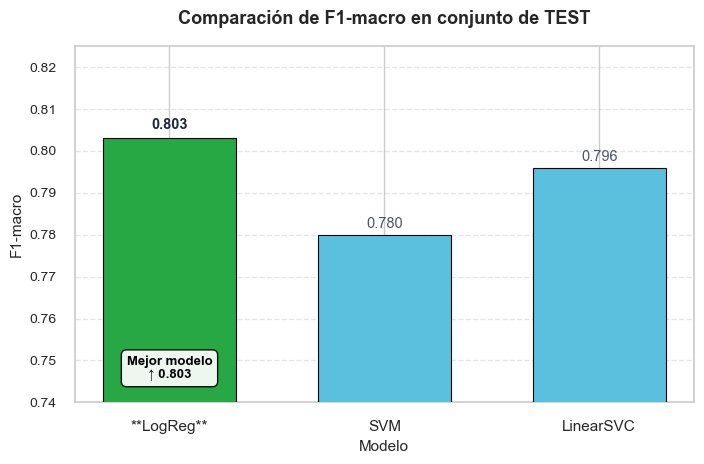

In [18]:
# Visualización de comparaciones

scores = {
    "LogReg": 0.803,
    "SVM": 0.780,
    "LinearSVC": 0.796
}

models = list(scores.keys())
f1_values = list(scores.values())

# Encontramos el mejor y su valor
best_model = max(scores, key=scores.get)
best_value = scores[best_model]

# Colores resaltados
colors = ['#5bc0de' if model != best_model else '#28a745' for model in models]

plt.figure(figsize=(7.2, 4.8), facecolor='white')

bars = plt.bar(
    models,
    f1_values,
    color=colors,
    width=0.62,
    edgecolor='black',
    linewidth=0.8,
    zorder=3
)

# Límites un poco más amplios y bonitos
plt.ylim(0.74, 0.825)

# Quitar líneas de cuadrícula verticales y dejar solo horizontales claras
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

# Etiquetas encima de las barras 
for bar, value, model in zip(bars, f1_values, models):
    offset = 0.0015 if model == best_model else 0.001
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + offset,
        f"{value:.3f}",
        ha='center',
        va='bottom',
        fontsize=10.5,
        fontweight='bold' if model == best_model else 'normal',
        color='#1f2937' if model == best_model else '#4b5563'
    )

# Resaltar el mejor modelo también en el eje x
tick_labels = []
for model in models:
    if model == best_model:
        tick_labels.append(f"**{model}**")
    else:
        tick_labels.append(model)

plt.xticks(ticks=range(len(models)), labels=tick_labels, fontsize=11, fontweight='medium')

plt.yticks(fontsize=10)
plt.ylabel("F1-macro", fontsize=11, fontweight='medium')
plt.xlabel("Modelo", fontsize=11, fontweight='medium')

# Título más impactante
plt.title("Comparación de F1-macro en conjunto de TEST", 
          fontsize=13, 
          fontweight='bold', 
          pad=16)

# Anotación al ganador
plt.text(
    models.index(best_model),
    0.745,
    f"Mejor modelo\n↑ {best_value:.3f}",
    ha='center',
    va='bottom',
    fontsize=9.5,
    color='#000000',
    fontweight='bold',
    bbox=dict(facecolor='white', edgecolor='#000000', boxstyle='round,pad=0.4', alpha=0.92)
)

# Mostrar
plt.tight_layout()
plt.show()

## Conclusiones finales y recomendaciones

### Validación y selección
- Se aplicó **cross-validation estratificada por grupos (asin)** con 5 folds.  
- **F1-macro CV = 0.803 ± 0.007**, asegurando una estimación confiable **sin fuga de información** entre reseñas de la misma película.  

---

### Conclusiones finales
- **Modelo ganador: Logistic Regression + Bag-of-Words (1-2 gram)**  
- **F1-macro TEST ≈ 0.803**, **accuracy ≈ 0.866** → Buen equilibrio entre precisión y recall en un dataset desbalanceado.  
- Cobertura negativa mejorada: ~72 % de las reviews negativas se identifican correctamente, lo cual es **crucial para moderación o alertas de producto**.  
- Proporciona **probabilidades de clase**, útiles para calibrar umbrales según el uso (p.ej., alertas automáticas o dashboards de satisfacción).

---

### Recomendaciones y pasos a seguir
1. **Implementar max_len robusto** (≈730 tokens) para truncar reseñas extremadamente largas y mejorar consistencia de features.  
2. **Explorar embeddings de películas** para capturar similitudes semánticas y mejorar predicción en items con pocas reviews.  
3. **Mantener group split por movie** en futuras particiones Train/Test para evitar fugas de información.  
4. **Considerar ajuste de umbral** usando probabilidades de Logistic Regression para optimizar la cobertura de reviews negativas según necesidad del negocio.  
5. **Monitorear el desempeño** periódicamente al añadir nuevas reseñas, especialmente si cambia la distribución de longitud o vocabulario.